<a href="https://colab.research.google.com/github/zehszo/IC-LogisticRegression/blob/main/IC_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**🎙️ Voice-Based Gender Recognition via Machine Learning**

**Objective:** To classify voices as male or female using acoustic attributes and Logistic Regression.

**Author:** José Pedro Rodrigues de Freitas | Undergraduate Research Project

This project demonstrates a complete Machine Learning pipeline for Voice Gender Recognition. By applying statistical outlier removal (IQR) and feature selection, we improved model stability and achieved a final accuracy of 97% on unseen data.

**📥 1. Environment Setup and Data Ingestion**

In this initial phase, we prepare the environment using the fundamental Python ecosystem for Data Science:

**🎲 Pandas & NumPy:** For matrix manipulation and tabular data structures.

**📉 Matplotlib & Seaborn:** For statistical visualization and Exploratory Data Analysis (EDA).

**🤖 Scikit-Learn:** For the end-to-end Machine Learning pipeline (preprocessing, modeling, and evaluation).

Technical Note: The dataset used is the Voice Gender Dataset, which consists of 3,168 samples of male and female voices, pre-processed via acoustic analysis.

In [640]:
# --- Fundamental Libraries ---
import pandas as pd
import numpy as np

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import heatmap

# --- Preprocessing & Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# --- Data Loading ---

try:
    df = pd.read_csv('voice.csv')

    if df['label'].dtype == 'object':
      df['label'] = df['label'].map({'male': 0, 'female': 1})

    X = df.drop('label', axis=1)
    y = df['label']

    print(f"✅ Dataset successfully loaded! Shape: {df.shape}")
    print(f"Missing values: {df.isnull().sum().sum()}")

except FileNotFoundError:
    print("❌ Error: 'voice.csv' not found. Please upload the file to the Colab 'Files' tab.")

✅ Dataset successfully loaded! Shape: (3168, 21)
Missing values: 0


**🧪 2. Baseline Model: Performance on Untreated Data**

Before any cleaning or feature engineering, we establish a Baseline. This step is crucial to demonstrate the impact of data quality on model performance. We will evaluate how a standard Logistic Regression handles outliers and unscaled features.

**📐 Data Splitting Strategy (70/20/10)**
We divide our dataset into three distinct sets:

Training (70%): Used for model learning.

Validation (20%): Used for hyperparameter tuning and outlier analysis.

Test (10%): Accessed at the very end to verify real-world performance.

In [641]:
# --- Initial Data Splitting ---
# 1. Separating the Final Test Set (10%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# 2. Separating Validation (20%) from the remaining 90%
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2222, random_state=42)

# Verification
print(f"Train: {len(X_train)/len(X):.1%}")
print(f"Validation: {len(X_val)/len(X):.1%}")
print(f"Test: {len(X_test)/len(X):.1%}")

Train: 70.0%
Validation: 20.0%
Test: 10.0%


**📊 Preliminary Exploratory Data Analysis (EDA)**

We now analyze the Histograms to observe the data distribution and the Correlation Matrix to identify redundant features (multicollinearity).

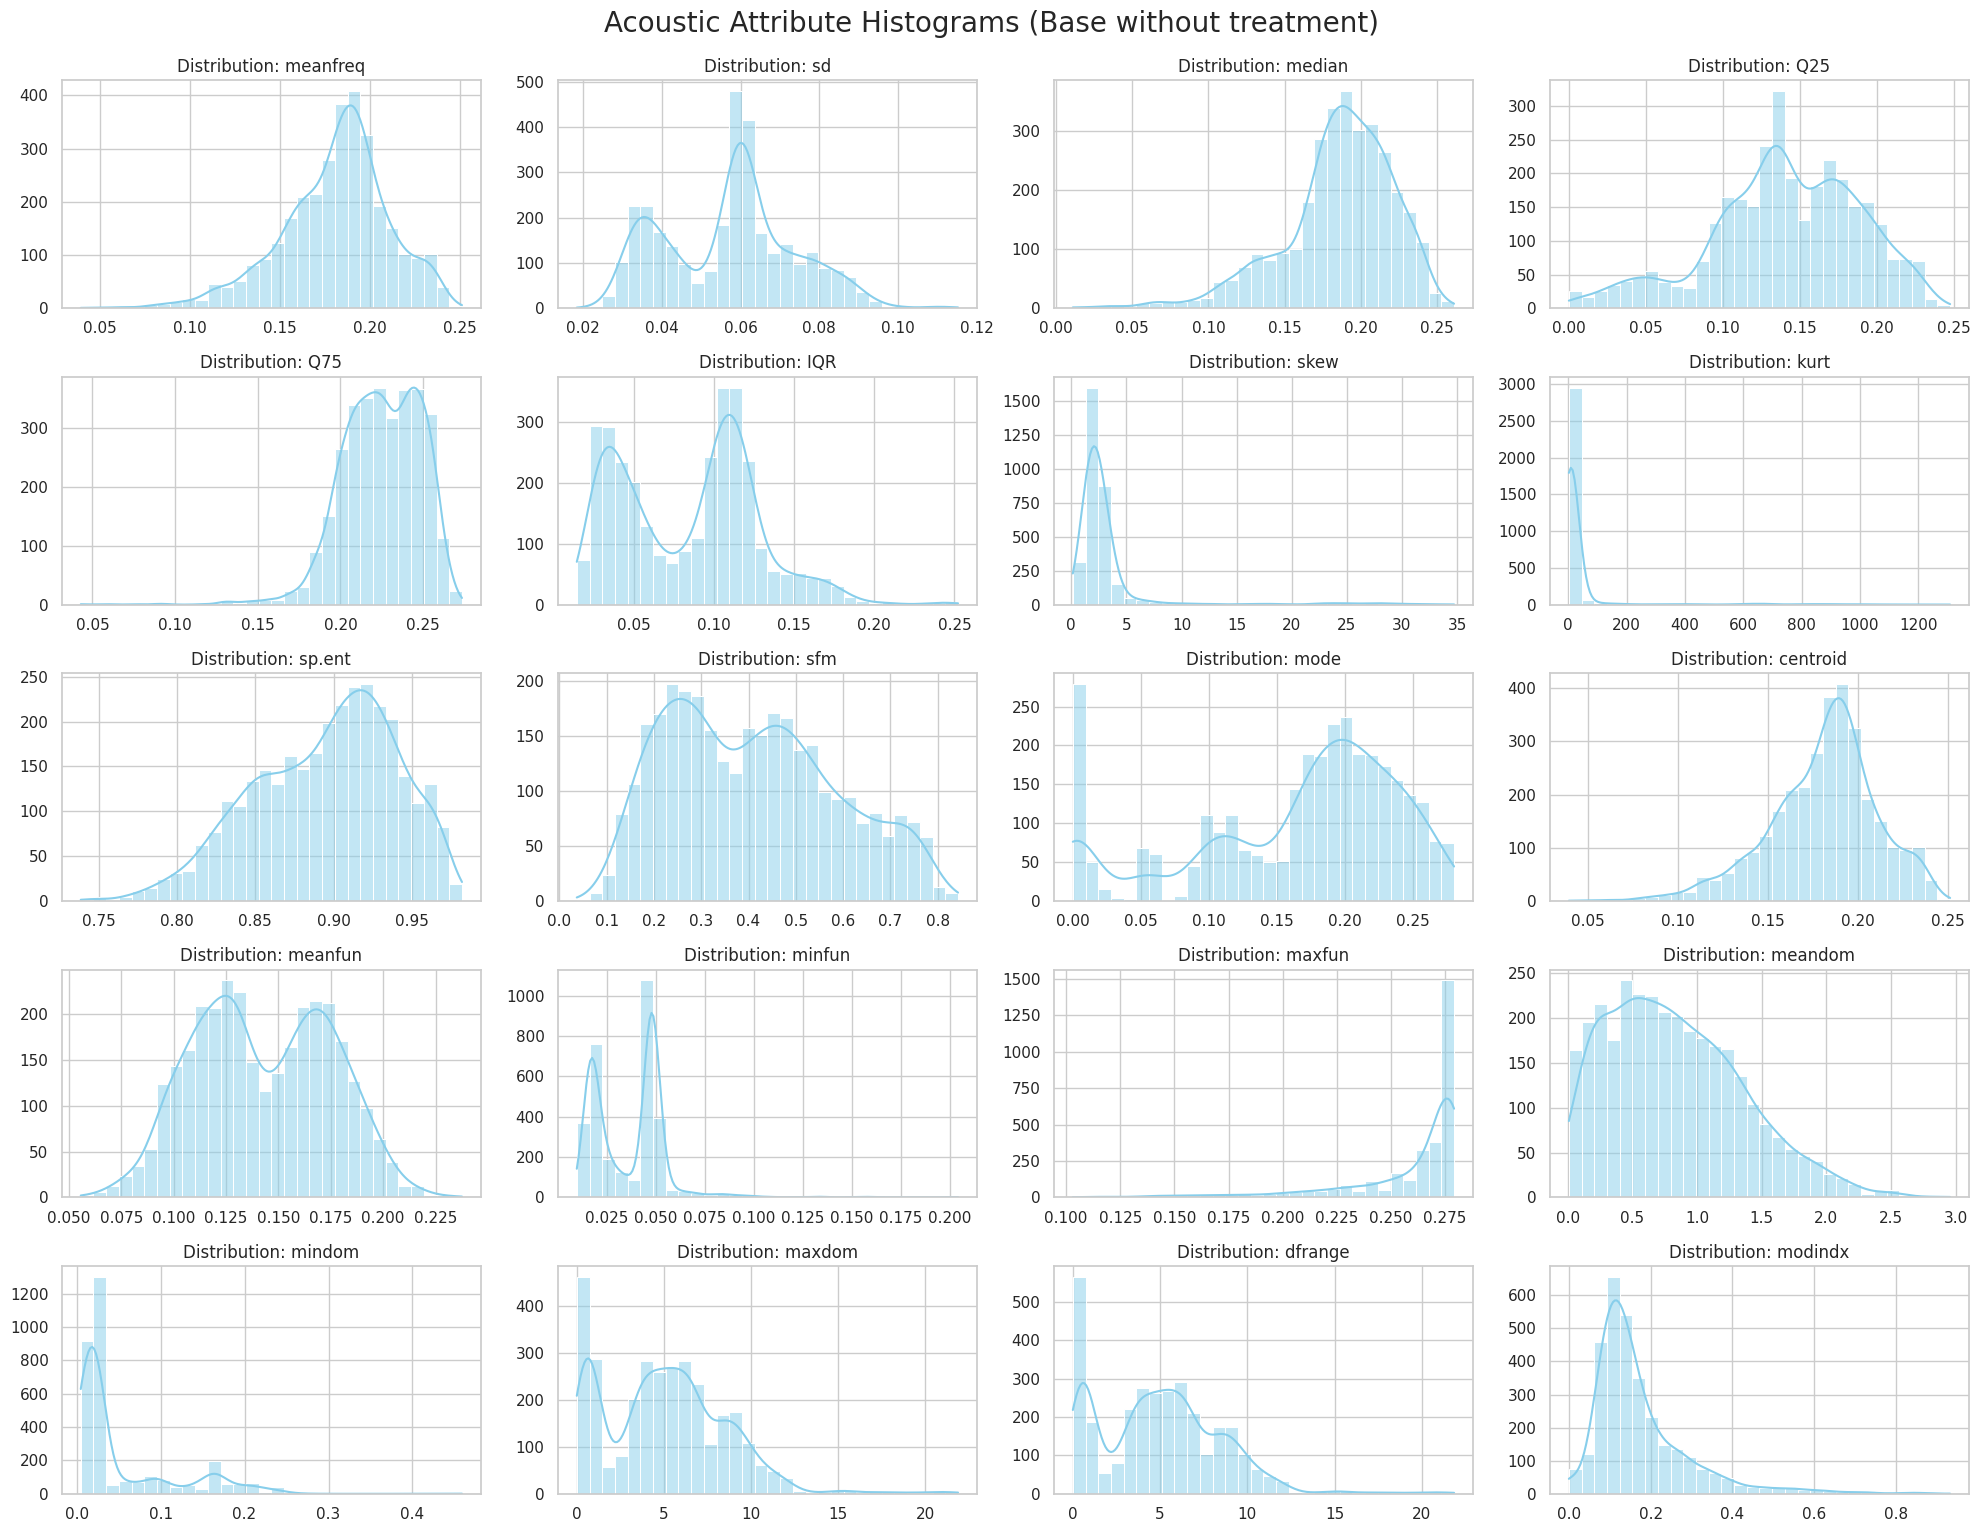

In [642]:
# --- Visualizing Distributions (Histograms) ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 15))

features = df.columns.drop('label')

for i, col in enumerate(features):
    plt.subplot(5, 4, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution: {col}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.suptitle('Acoustic Attribute Histograms (Base without treatment)', fontsize=20, y=1.02)
plt.show()

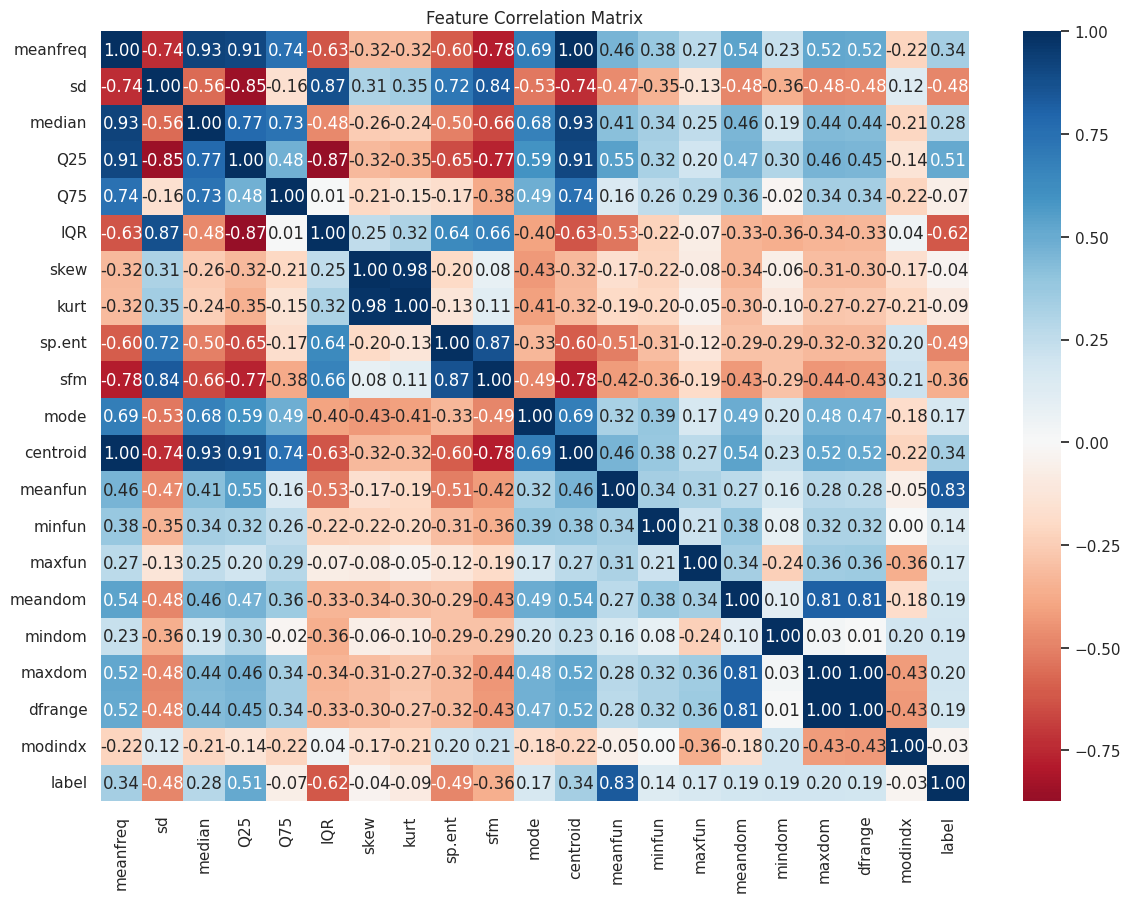

In [643]:
# --- Visualizing the Correlation Matrix ---
plt.figure(figsize=(14, 10))
# Plotting with annotation to show the reduced redundancy
sns.heatmap(df.corr(), annot=True, cmap='RdBu', fmt='.2f', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

**📉 Baseline Performance**

Note: Here, we run the model on raw, unscaled data to witness the impact of outliers and feature magnitude on the accuracy score (around 0.87).

In [644]:
# Baseline Logistic Regression (No Scaling / No Outlier Removal)
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

Y_pred = model.predict(X_val)

**📊 3. Baseline Performance Evaluation**

In this section, we take a deep dive into the Baseline Model's performance. Accuracy alone can be misleading; therefore, we use a Confusion Matrix and a Classification Report to understand where the model is failing—specifically, identifying which gender is more frequently misclassified.

**📉 Performance Metrics**

We evaluate the model on the Validation Set to observe:

**Precision:** How many of the positive predictions were actually correct?

**Recall:** How many of the actual positive cases did the model find?

**F1-Score:** The harmonic mean of Precision and Recall (crucial for balanced classification).

In [645]:
# 1. Accuracy Check
print(f"🎯 Baseline Validation Accuracy: {model.score(X_val, y_val):.4f}")

🎯 Baseline Validation Accuracy: 0.8770


Text(0.5, 1.0, 'Confusion Matrix')

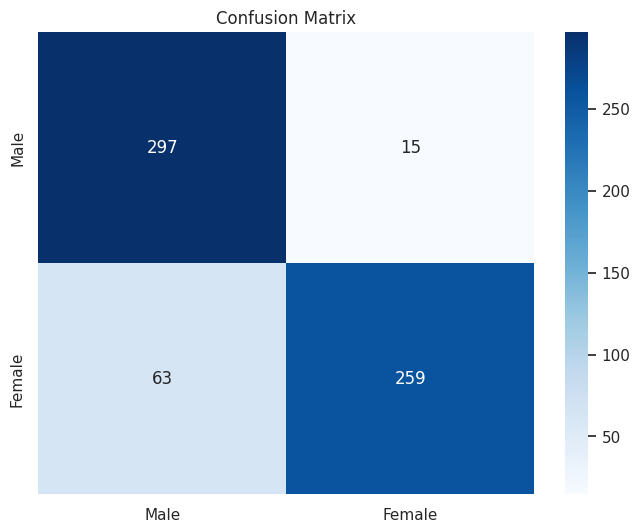

In [646]:
# 2. Plotting the Confusion Matrix Heatmap
cm = confusion_matrix(y_val, Y_pred)
plt.figure(figsize=(8, 6))
heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.title('Confusion Matrix')



In [647]:
# 3. Generating the Classification Report
print("\n📋 Baseline Classification Report:")
print(classification_report(y_val, Y_pred))


📋 Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88       312
           1       0.95      0.80      0.87       322

    accuracy                           0.88       634
   macro avg       0.89      0.88      0.88       634
weighted avg       0.89      0.88      0.88       634



**🛠️ 4. Data Engineering: Refinement and Optimization**

Now that we have identified the limitations of our Baseline, we apply a Data Cleaning Pipeline. Our goal is to reduce noise, eliminate redundant information, and stabilize the model's decision boundary.

**🔗 Phase 1:** Feature Selection (Multicollinearity Removal)
Some acoustic features, such as centroid and meanfreq, are mathematically redundant (in this case, correlation > 0.7). High multicollinearity can destabilize Logistic Regression coefficients. We automate the removal of these "mirror" features to create a leaner, more efficient model.

In [648]:
# --- Correlation-Based Feature Selection ---
# 1. Calculating absolute correlation matrix
corr_matrix = X.corr().abs()

# 2. Selecting the upper triangle to avoid self-comparison
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Identifying features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print(f"Redundant columns identified. (Corr > 0.9): {to_drop}")

# 4. Dropping redundant features
X_filtered = X.drop(columns=to_drop)

print(f"Total columns removed: {len(to_drop)}")
print(f"Remaining columns: {list(X_filtered.columns)}")

Redundant columns identified. (Corr > 0.9): ['median', 'Q25', 'kurt', 'centroid', 'dfrange']
Total columns removed: 5
Remaining columns: ['meanfreq', 'sd', 'Q75', 'IQR', 'skew', 'sp.ent', 'sfm', 'mode', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'modindx']


**🧹 Phase 2: Outlier Treatment (Interquartile Range - IQR)**

Acoustic recordings often contain spikes or background noise that manifest as outliers. We use Tukey’s Method (IQR) to remove samples that fall outside the typical distribution limits ($Q1 - 3 \times IQR$ and $Q3 + 3 \times IQR$). Empiric tests shown that 3 is the best value to apply at the limits.

In [649]:
# --- Outlier Removal via IQR ---
Q1 = X_filtered.quantile(0.25)
Q3 = X_filtered.quantile(0.75)
IQR = Q3 - Q1

# Define limits
lower_limit = Q1 - 3 * IQR
upper_limit = Q3 + 3 * IQR

# Filtering the dataset
# We keep rows that are within the bounds for ALL columns
non_outliers_mask = ~((X_filtered < lower_limit) | (X_filtered > upper_limit)).any(axis=1)
df_final = df.loc[non_outliers_mask, list(X_filtered.columns) + ['label']]

print(f"Lines before filter: {len(df)}")
print(f"Linhas after outlier removal: {len(df_final)}")

Lines before filter: 3168
Linhas after outlier removal: 2808


**📊 5. Post-Processing Visualization: Impact of Data Refinement**

After applying Correlation-based Filtering and IQR Outlier Removal, we re-evaluate the data distributions. This visual check confirms that the dataset is now more robust and less susceptible to the "pull" of extreme values.

**📉 Histogram Analysis: Original vs. Refined**

Analytical Note: Notice the subtle but vital shift in the distributions. The "long tails" (extreme outliers) have been clipped, and the kernel density estimates (KDE) are now smoother. This results in a cleaner Normal Distribution (Bell Curve) for several features, which is the ideal scenario for the mathematical assumptions of Logistic Regression.

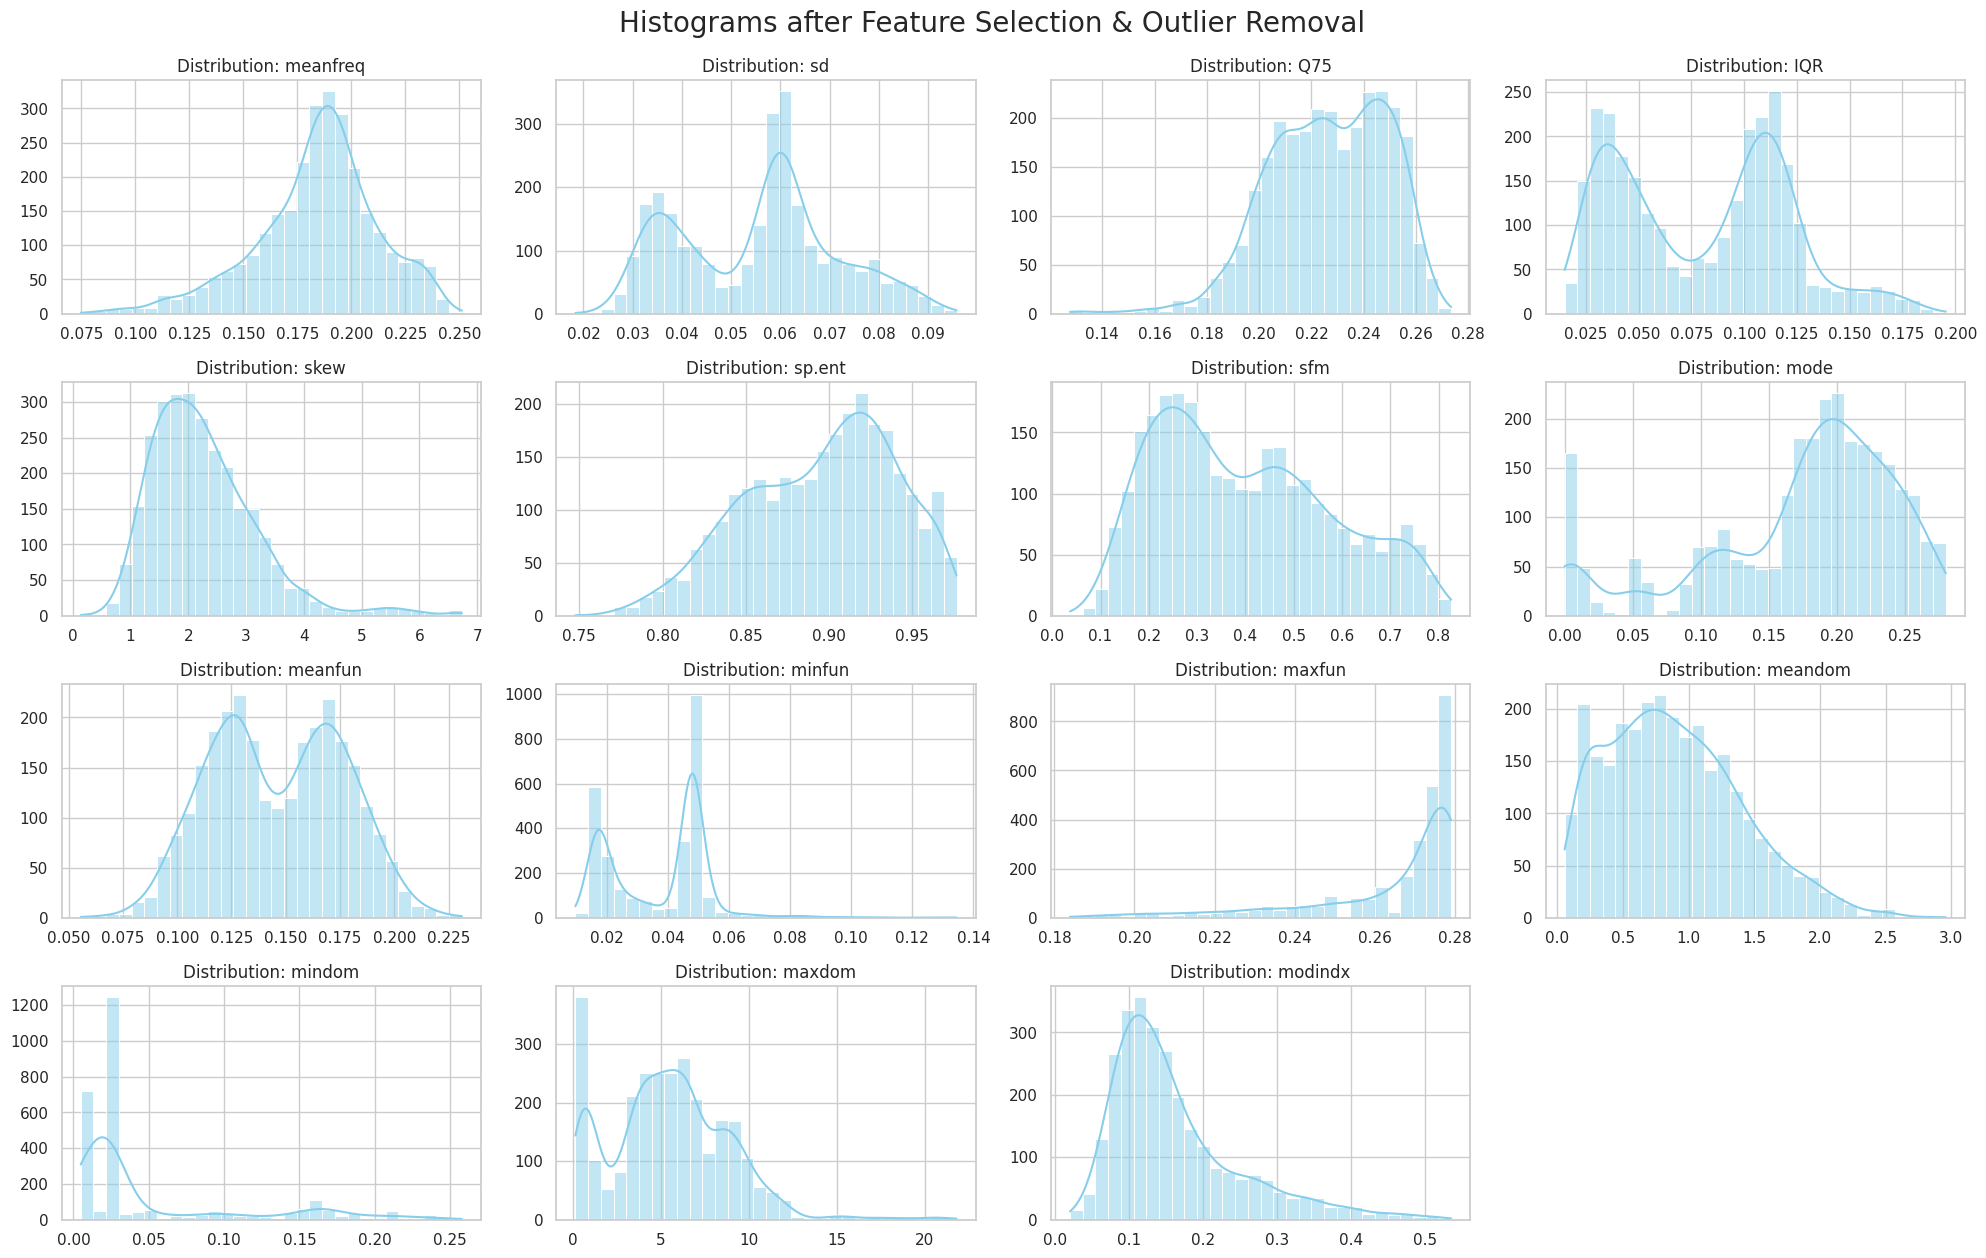

In [650]:
# --- Visualizing Distributions after Refinement ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 15))

features = df_final.columns.drop('label')

for i, col in enumerate(features):
    plt.subplot(5, 4, i + 1)
    sns.histplot(df_final[col], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution: {col}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.suptitle('Histograms after Feature Selection & Outlier Removal', fontsize=20, y=1.02)
plt.show()

**🔗 Refined Correlation Matrix**

By removing redundant features (those with correlation > 0.90), we eliminated Multicollinearity. The new heatmap shows a much more diverse set of predictors, ensuring that each feature contributes unique information to the model's decision-making process.

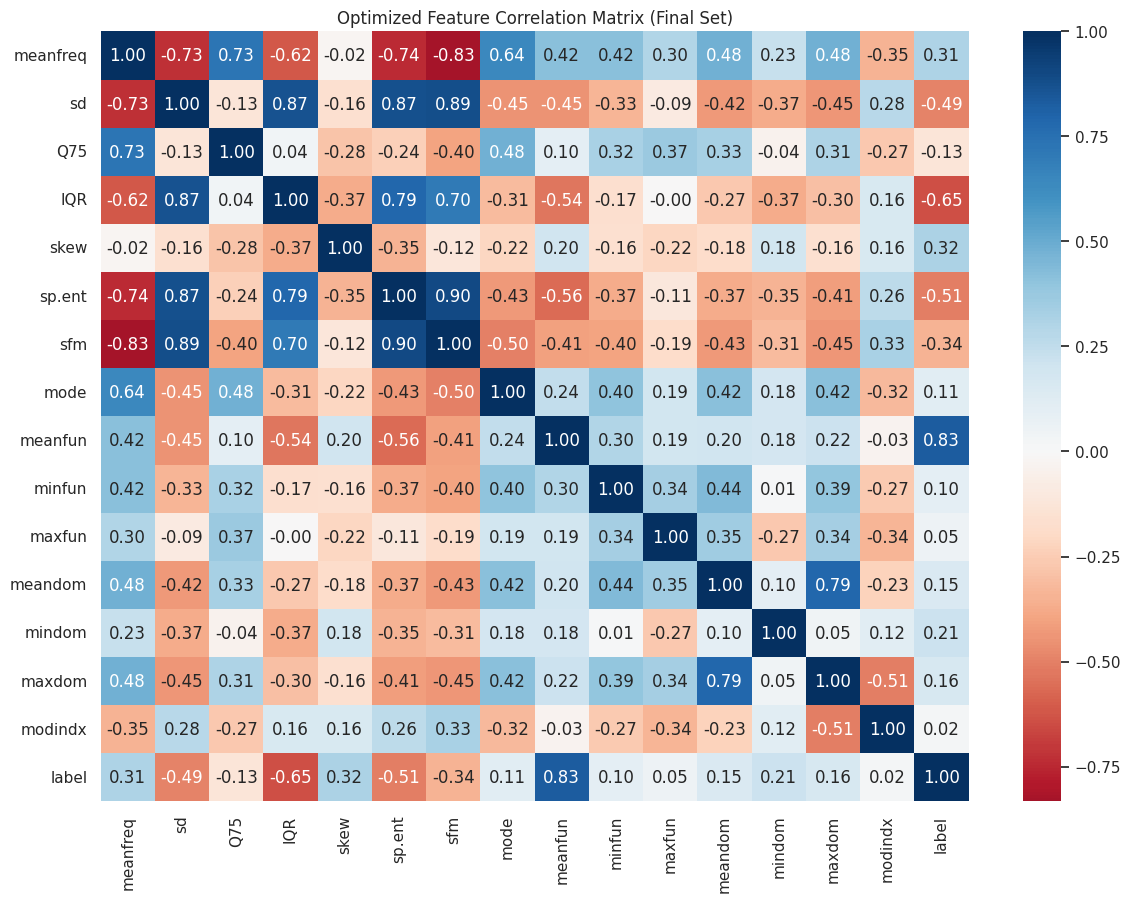

In [651]:
# --- Visualizing the Clean Correlation Matrix ---
plt.figure(figsize=(14, 10))
# Plotting with annotation to show the reduced redundancy
sns.heatmap(df_final.corr(), annot=True, cmap='RdBu', fmt='.2f', center=0)
plt.title('Optimized Feature Correlation Matrix (Final Set)')
plt.show()

**📐 Phase 3: Final Data Splitting (70/20/10 Re-alignment)**

With the clean and optimized data, we re-split the sets to ensure the model trains on high-quality information while maintaining the strict 70/20 split for training and validation.

In [652]:
# New sets
X_f = df_final.drop('label', axis=1)
y_f = df_final['label']

# --- Re-splitting Clean Data ---
# Note: X_test remains untouched (from the original raw split) to prove the model's generalization on real-world noisy data later.
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X_f, y_f, test_size=0.2222, random_state=42)

# Verification
print(f"Train: {len(X_train_final)/len(X_f):.1%}")
print(f"Validation: {len(X_val)/len(X_f):.1%}")

Train: 77.8%
Validation: 22.6%


**⚖️ 6. Feature Scaling: Standardizing the Predictors**

Logistic Regression is a distance-based algorithm that assumes all features contribute equally to the final prediction. Since our acoustic features (like meanfun and duration) have vastly different scales, we apply Standardization (Z-score Normalization).

**📐 The StandardScaler Approach**

We transform each feature so that it has:

- Mean ($\mu$) = 0

- Standard Deviation ($\sigma$) = 1

We fit the scaler only on the Training Set to learn the parameters ($\mu$ and $\sigma$), and then transform both the Training and Validation/Test sets. This prevents Data Leakage by ensuring the model doesn't "peek" at the distribution of the unseen data.

In [653]:
# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit and transform the data
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)

# Ensuring we use only the optimized feature set
X_test_final = X_test[list(X_filtered.columns)]
X_test_final_scaled = scaler.transform(X_test_final)

print("✅ Feature Scaling Complete.")

✅ Feature Scaling Complete.


**🏆 7. Model Training & Refined Performance**

With the features selected, outliers removed, and data standardized, we now train our Logistic Regression model. By feeding it high-quality data, we expect a significant jump in stability and accuracy compared to our baseline.

**📈 Optimized Model Evaluation**

We analyze the performance on the Validation Set to confirm the impact of our data treatment.

In [654]:
# --- Training the Refined Model ---
model.fit(X_train_scaled, y_train_final)

# --- Performance Metrics ---
Y_pred = model.predict(X_val_scaled)

In [655]:
# 1. Accuracy Check
print(f"🎯 Refined Validation Accuracy: {accuracy_score(y_val_final, Y_pred):.4f}")

🎯 Refined Validation Accuracy: 0.9583


<Axes: >

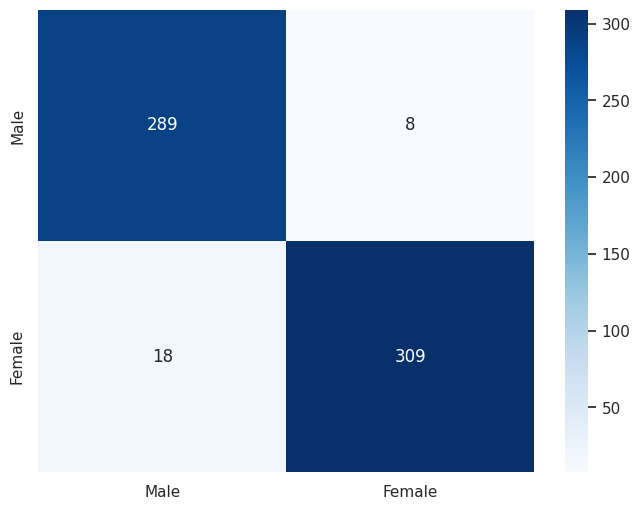

In [656]:
# 2. Plotting the Confusion Matrix Heatmap
cm = confusion_matrix(y_val_final, Y_pred)
plt.figure(figsize=(8, 6))
heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])

In [657]:
# 3. Generating the Classification Report
print("\n📋 Optimized Classification Report:")
print(classification_report(y_val_final, Y_pred))


📋 Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       297
           1       0.97      0.94      0.96       327

    accuracy                           0.96       624
   macro avg       0.96      0.96      0.96       624
weighted avg       0.96      0.96      0.96       624



**🏁 8. Final Model Validation (Unseen Test Data)**

The ultimate test for any Machine Learning model is its performance on the Final Test Set (the 10% we locked away at the beginning). These samples were never seen during training, outlier filtering, or feature selection, providing an unbiased estimate of how the model will behave in a real-world production environment.

In [658]:
# 1. Make final preds
y_pred_final = model.predict(X_test_final_scaled)

# 2. Calculating the final accuracy
final_accuracy = model.score(X_test_final_scaled, y_test)
print(f"--- FINAL ACCURACY OF THE PROJECT ---")
print(f"🎯Accuracy in test data: {final_accuracy:.4f}")

--- FINAL ACCURACY OF THE PROJECT ---
🎯Accuracy in test data: 0.9748


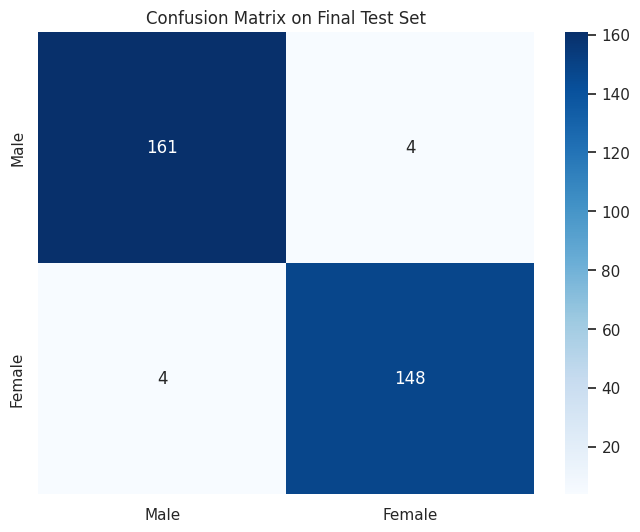

In [659]:
# 3. Plotting the Confusion Matrix heatmap

cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=['Male', 'Female'], yticklabels=['Male', 'Female'])
plt.title('Confusion Matrix on Final Test Set')
plt.show()

In [660]:
# 4. Generating the Classification Report

print("\n📋 Final Classification Report:")
print(classification_report(y_test, y_pred_final))


📋 Final Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       165
           1       0.97      0.97      0.97       152

    accuracy                           0.97       317
   macro avg       0.97      0.97      0.97       317
weighted avg       0.97      0.97      0.97       317



**💡Conclusion:** The high accuracy on the unseen test set confirms that our data engineering pipeline was successful. By removing outliers and redundancy, we built a robust and generalized model capable of classifying gender by voice with high precision, avoiding the common trap of overfitting 🥳.